# T9 · Optimizers and loss functions: physics versus black box

Three model families on the same problems (`physprior.optim`):

- `physics`: the closed-form law with 1-3 constants trainable;
- `pinn`: law plus a penalised network correction (hydrogen), or the
  residual PINN whose network is the solution of the ODE/PDE (oscillator,
  heat equation);
- `nn`: a tanh MLP, width 32, depth 3.

The full study (`physprior.optim.report.run_all()`) writes `results/optim/`.
This notebook runs two small live examples and then reads those results.
Learning rates were chosen on the tuning seeds 3/7/19; reported numbers are on
11/23/42.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


## 1. Live: one problem, three models, two optimizers

The damped oscillator `x'' + 2 gamma x' + omega0^2 x = 0` with gamma and
omega0 unknown. Adam against L-BFGS on each model, and Levenberg-Marquardt on
the physics model, counting loss-and-gradient evaluations.

In [2]:
import pandas as pd
from physprior.optim import optimizers_study as O
rows = []
for model in ("physics", "pinn", "nn"):
    for opt, lr in (("adam", 1e-2), ("lbfgs", 1.0)):
        r, _, _ = O.run_one(O.RunSpec("oscillator", model, opt, lr, 11, 600))
        rows.append(r)
rows.append(O.run_lm("oscillator", 11))
live = pd.DataFrame(rows)
live[["model", "optimizer", "n_params", "evals_used", "evals_to_tol",
      "final_data_loss", "nrmse_in", "nrmse_out", "param_err_pct"]]

,model,optimizer,n_params,evals_used,evals_to_tol,final_data_loss,nrmse_in,nrmse_out,param_err_pct
0,physics,adam,2,600,120.0,0.002487,0.011054,0.012687,1.931454
1,physics,lbfgs,2,600,8.0,0.002487,0.011054,0.012687,1.931454
2,pinn,adam,2211,600,NaN,0.006283,0.081140,0.323694,20.380912
3,pinn,lbfgs,2211,212,NaN,inf,inf,inf,98.757773
4,nn,adam,2209,600,159.0,0.001516,0.050348,1.239117,NaN
5,nn,lbfgs,2209,623,265.0,0.001511,0.059703,5.666852,NaN
6,physics,lm,2,23,8.0,0.002487,0.011054,0.012687,1.931454


## 2. Live: the Hessian at the solution

The physics model has two parameters, so its Hessian is 2 x 2. The black box
has about 2200, and most of its eigenvalues are zero to round-off.

In [3]:
import torch
from physprior.optim import problems as Pb
task = Pb.oscillator()
for kind in ("physics", "nn"):
    m = Pb.Model(task, kind, seed=11)
    opt = torch.optim.LBFGS(m.parameters(), max_iter=400, line_search_fn="strong_wolfe")
    def closure():
        opt.zero_grad(); l = m.loss(); l.backward(); return l
    opt.step(closure)
    eig = np.linalg.eigvalsh(Pb.full_hessian(m.loss, m.parameters()))[::-1]
    lmax = eig[0]
    n_sharp = int(np.sum(eig > 1e-3 * lmax))
    flat = float(np.mean(np.abs(eig) < 1e-6 * lmax))
    print(f"{kind:8s} params {eig.size:5d}  lambda_max {lmax:.3g}  "
          f"sharp (> 1e-3 lambda_max) {n_sharp}  flat fraction {flat:.3f}  "
          f"lambda_max / lambda_min {lmax / eig[-1]:.3g}")

physics  params     2  lambda_max 60  sharp (> 1e-3 lambda_max) 2  flat fraction 0.000  lambda_max / lambda_min 165


nn       params  2209  lambda_max 2.5e+04  sharp (> 1e-3 lambda_max) 6  flat fraction 0.976  lambda_max / lambda_min -2.09e+05


For the network, a negative `lambda_max / lambda_min` means the smallest
eigenvalue is negative: the end point is not a strict minimum, and the ratio
is not a condition number. Most of its eigenvalues are zero to within 1e-6 of
the largest, which is what "flat directions" means in practice.

## 3. The full study: learning-rate sensitivity and training curves

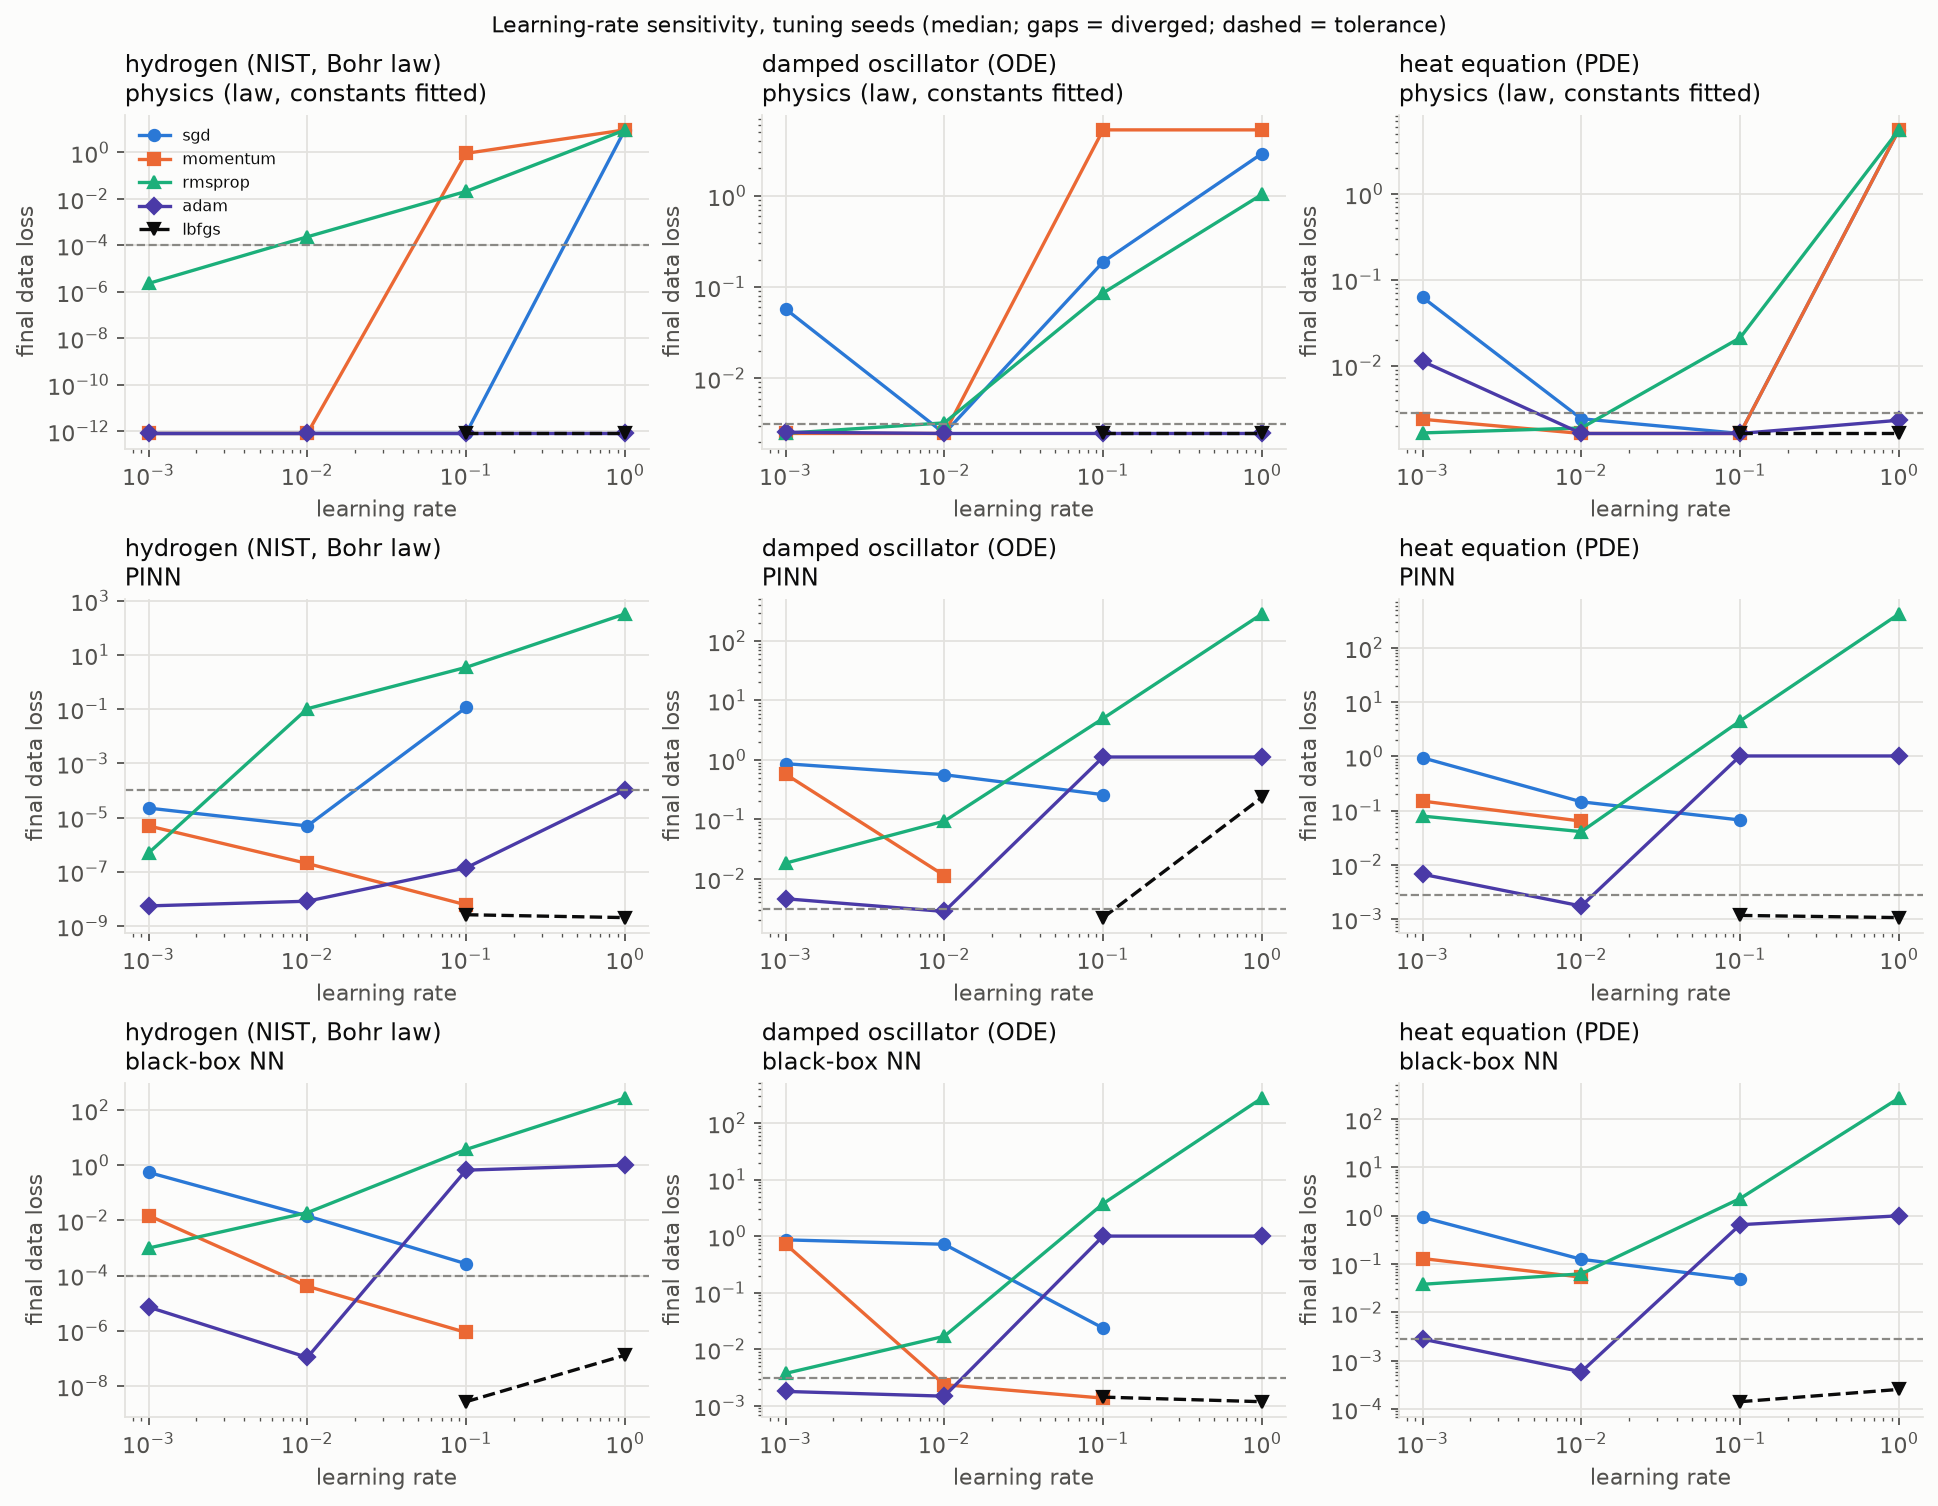

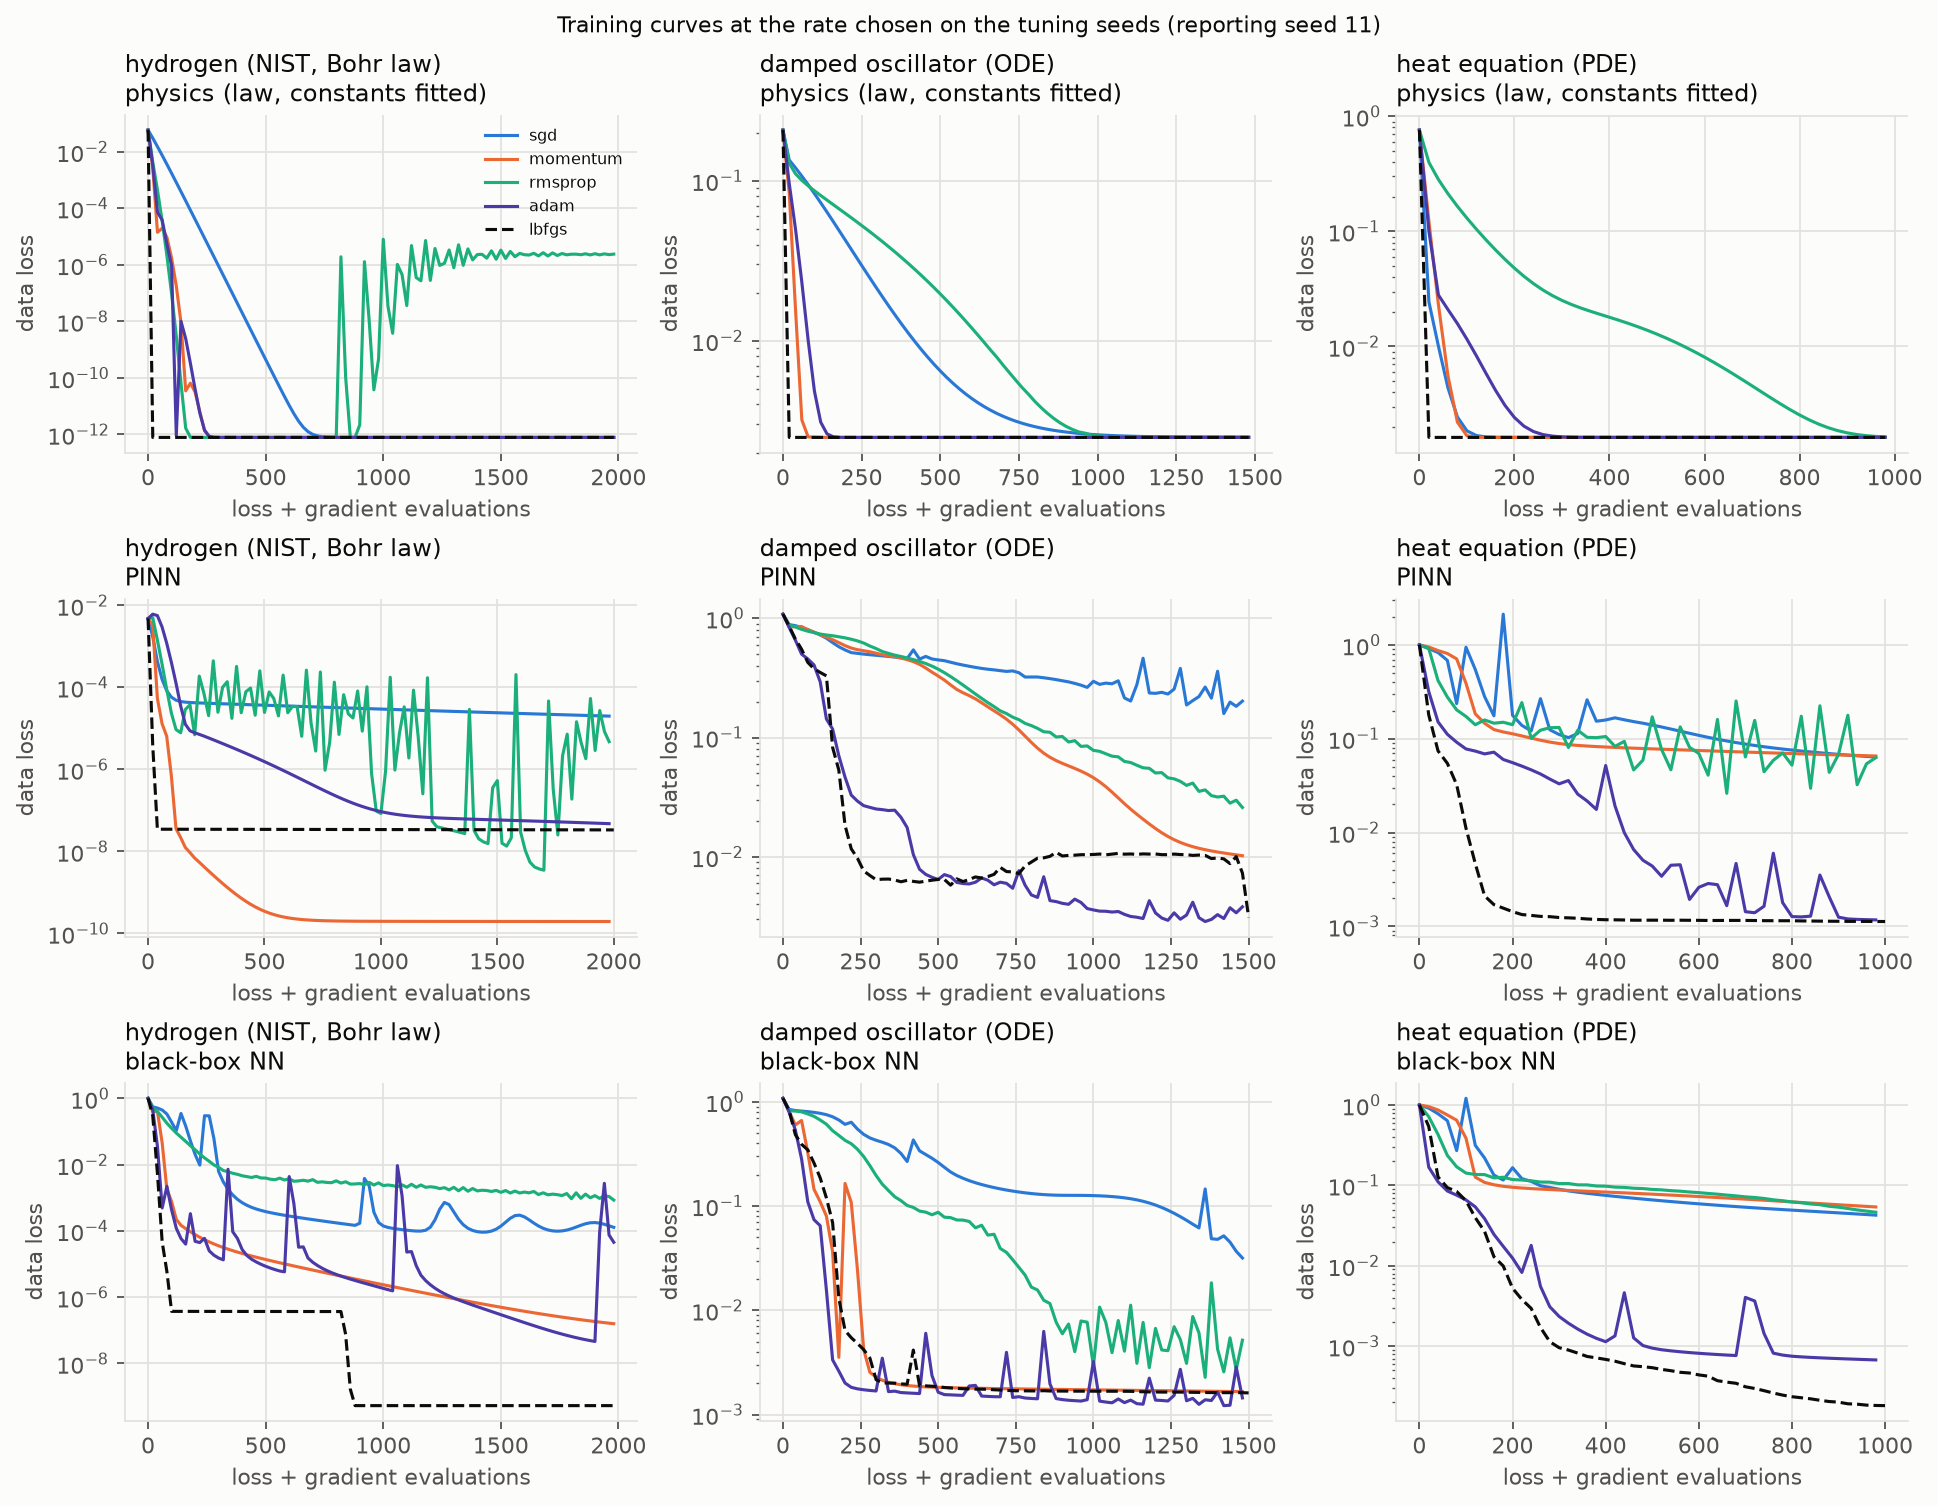

In [4]:
from IPython.display import Image, display, Markdown
from physprior.config import get_settings
from physprior.io import load_table
fig_dir = get_settings().figures_dir / "optim"
def show(name):
    p = fig_dir / f"{name}.png"
    display(Image(str(p)) if p.exists() else Markdown(f"*{name}: run the study first*"))
show("03_lr_sensitivity"); show("04_loss_curves")

In [5]:
from physprior.optim.optimizers_study import summarise
s = summarise(load_table("optim", "optimizers"))
s[["task", "model", "optimizer", "lr", "n_params", "evals_to_tol", "failure_rate",
   "final_data_loss", "nrmse_in", "nrmse_out", "param_err_pct"]]

,task,model,optimizer,lr,n_params,evals_to_tol,failure_rate,final_data_loss,nrmse_in,nrmse_out,param_err_pct
0,heat,nn,adam,0.010,2241,387.0,0.000000,6.674261e-04,1.162740e-01,0.194157,NaN
1,heat,nn,lbfgs,0.100,2241,244.0,0.000000,3.323970e-04,1.544128e-01,0.519945,NaN
2,heat,nn,momentum,0.010,2241,NaN,1.000000,4.806942e-02,3.151688e-01,0.386133,NaN
3,heat,nn,rmsprop,0.001,2241,NaN,1.000000,4.260168e-02,2.889147e-01,0.250243,NaN
4,heat,nn,sgd,0.100,2241,NaN,1.000000,4.225271e-02,3.229762e-01,0.390778,NaN
5,heat,physics,adam,0.010,3,137.0,0.000000,1.620860e-03,9.343832e-03,0.009339,1.335238
6,heat,physics,lbfgs,1.000,3,9.0,0.000000,1.620860e-03,9.343831e-03,0.009339,1.335238
7,heat,physics,lm,NaN,3,9.0,0.000000,1.620860e-03,9.343832e-03,0.009339,1.335238
8,heat,physics,momentum,0.010,3,80.0,0.000000,1.620860e-03,9.343832e-03,0.009339,1.335238
9,heat,physics,rmsprop,0.001,3,783.0,0.000000,1.629579e-03,1.233298e-02,0.013965,1.994399


## 4. Curvature and the PINN's two loss terms

Top: the Hessian spectrum at the Adam solution. Bottom: the ratio of the
gradient norms of the physics and data terms over the PINN's network weights
during training. A ratio far from one means one term steers the shared
weights and the other is nearly invisible to the optimizer (Wang, Teng &
Perdikaris 2021).

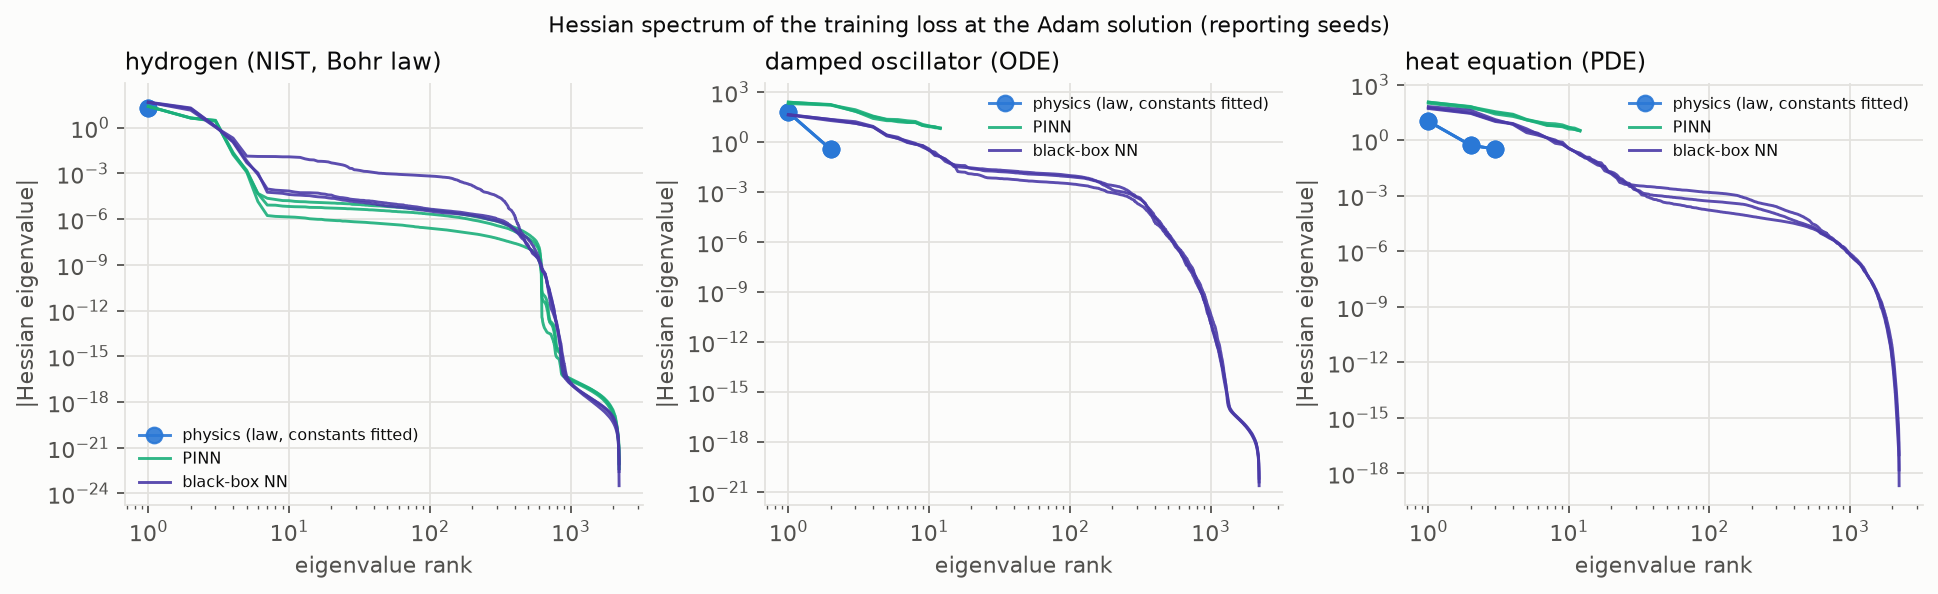

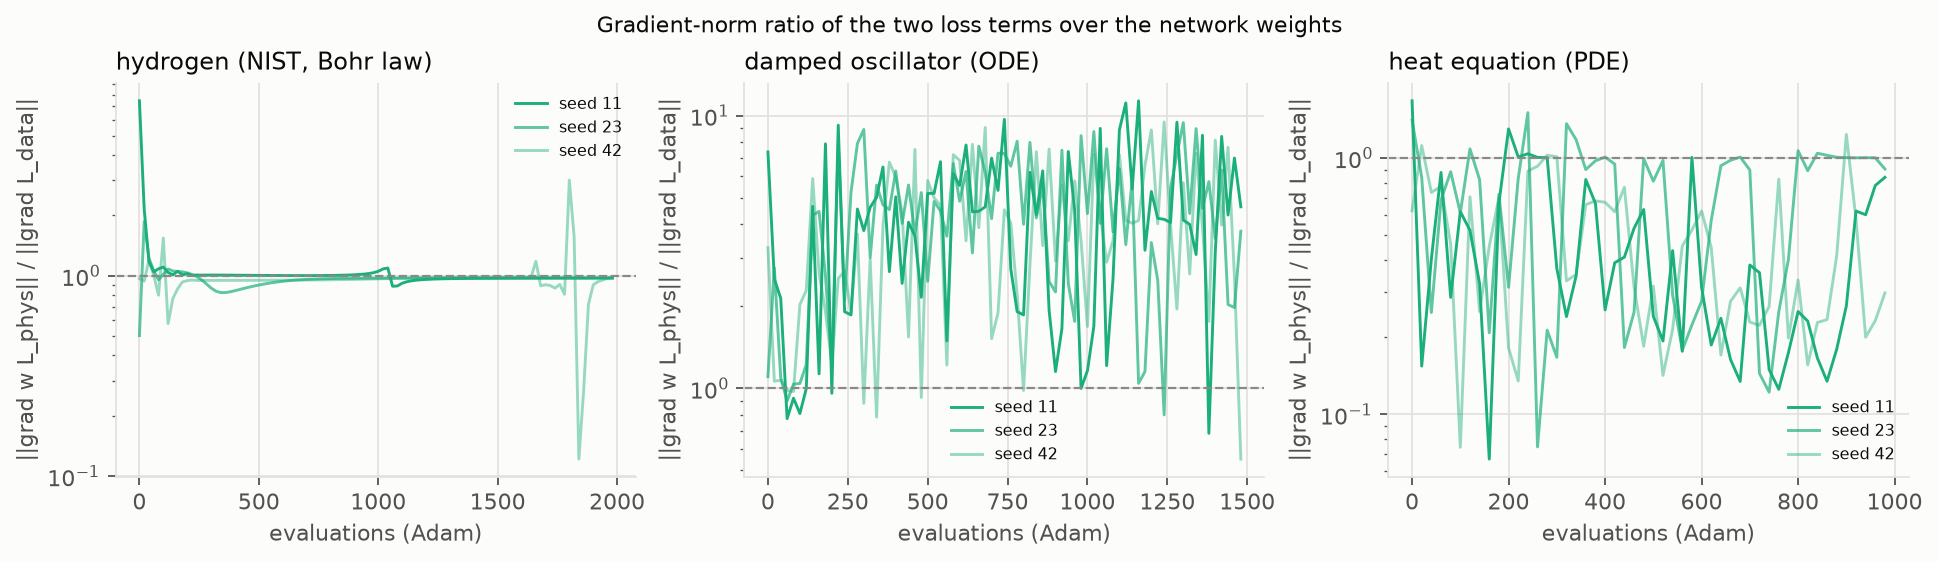

,task,model,optimizer,n_params,lambda_max,n_sharp,frac_flat,n_negative,cond,phys_block_cond,lmax_data,lmax_phys,phys_over_data
0,heat,nn,adam,2241,57.241627,15.0,0.841589,144.0,NaN,NaN,NaN,NaN,NaN
1,heat,nn,lbfgs,2241,178.496695,17.0,0.880411,117.0,NaN,NaN,NaN,NaN,NaN
2,heat,physics,adam,3,10.594322,3.0,0.000000,0.0,31.911694,31.911694,NaN,NaN,NaN
3,heat,physics,lbfgs,3,10.594322,3.0,0.000000,0.0,31.911694,31.911694,NaN,NaN,NaN
4,heat,pinn,adam,2244,114.646604,NaN,NaN,NaN,NaN,inf,103.699429,25.888470,0.249649
5,heat,pinn,lbfgs,2244,436.725626,NaN,NaN,NaN,NaN,inf,404.558726,120.397038,0.297601
6,hydrogen,nn,adam,2209,46.478321,4.0,0.992304,6.0,NaN,NaN,NaN,NaN,NaN
7,hydrogen,nn,lbfgs,2209,215.917328,4.0,0.996831,0.0,NaN,NaN,NaN,NaN,NaN
8,hydrogen,physics,adam,1,18.852973,1.0,0.000000,0.0,1.000000,1.000000,NaN,NaN,NaN
9,hydrogen,physics,lbfgs,1,18.852973,1.0,0.000000,0.0,1.000000,1.000000,NaN,NaN,NaN


In [6]:
show("05_hessian_spectra"); show("06_grad_ratio")
from physprior.io import load_json
from physprior.optim.report import curvature_table
curvature_table(load_table("optim", "curvature"), load_json("optim", "hessian_eigenvalues"))

## 5. Loss functions under three kinds of noise

MSE is the Gaussian likelihood. With heavy-tailed noise or outliers it gives
every large residual a quadratic pull, which biases a fitted constant; L1,
Huber and Cauchy cap that pull. The black box has no constant to bias, but its
curve bends toward the outliers.

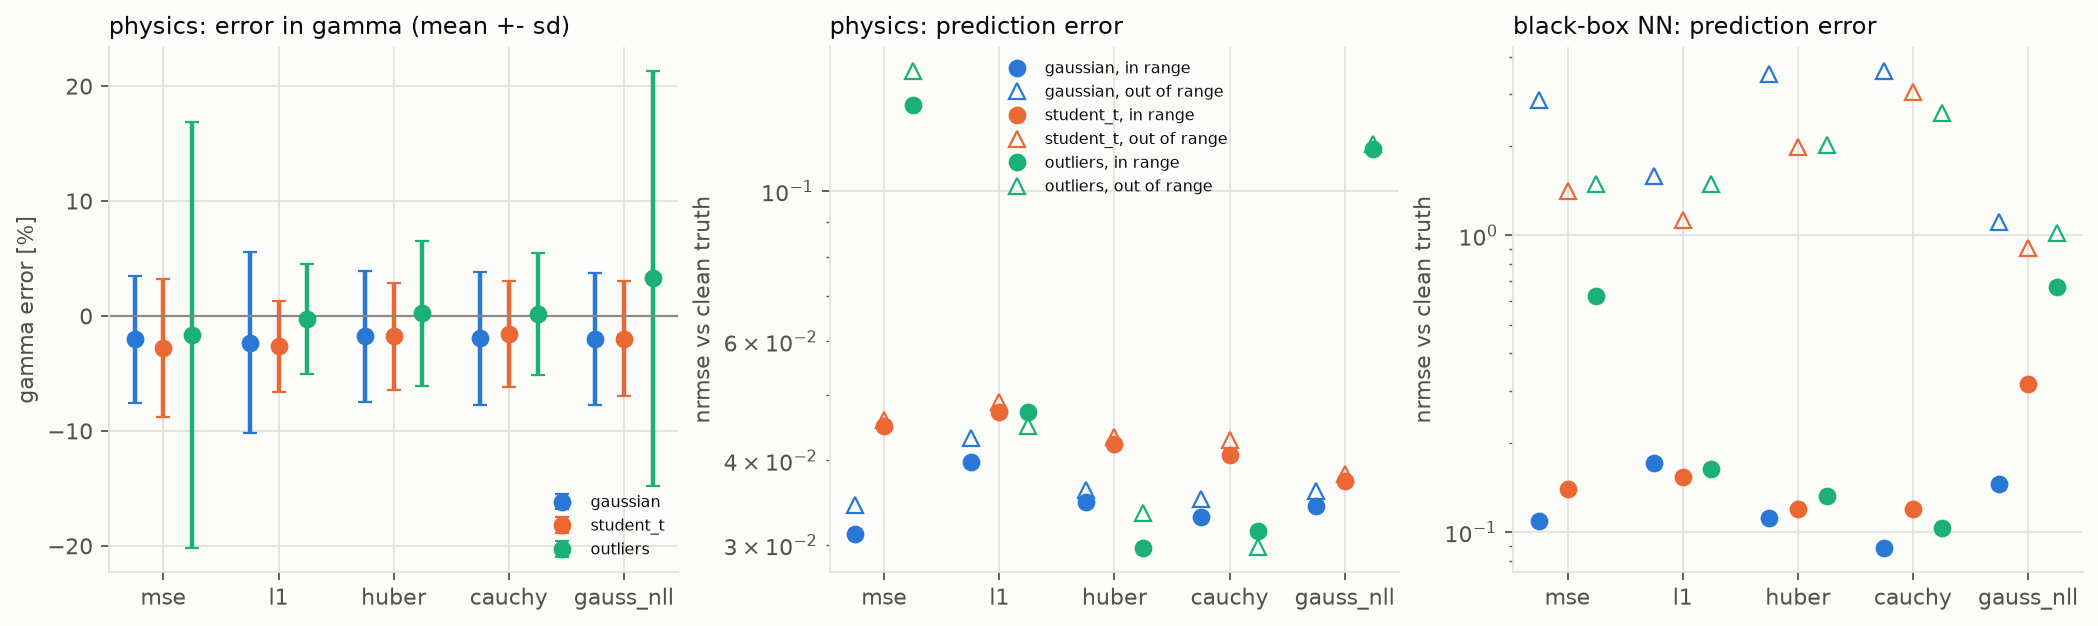

,noise,loss,gamma_bias_pct,gamma_sd_pct,gamma_bias_z,nrmse_in,nrmse_out
15,gaussian,cauchy,-1.938394,5.770181,-1.163706,0.033018,0.035090
16,gaussian,gauss_nll,-2.019047,5.753149,-1.215714,0.034234,0.036095
17,gaussian,huber,-1.776482,5.729371,-1.074099,0.034772,0.036212
18,gaussian,l1,-2.322425,7.868902,-1.022394,0.039812,0.043106
19,gaussian,mse,-2.031478,5.504945,-1.278350,0.031170,0.034383
20,outliers,cauchy,0.190482,5.297615,0.124556,0.031496,0.029764
21,outliers,gauss_nll,3.266758,18.039083,0.627326,0.115241,0.117543
22,outliers,huber,0.218230,6.270164,0.120566,0.029658,0.033424
23,outliers,l1,-0.243015,4.795910,-0.175531,0.047099,0.045013
24,outliers,mse,-1.666750,18.545099,-0.311338,0.134219,0.150490


In [7]:
show("07_loss_functions")
ls = load_table("optim", "losses_summary")
ls[ls.model == "physics"][["noise", "loss", "gamma_bias_pct", "gamma_sd_pct", "gamma_bias_z",
                           "nrmse_in", "nrmse_out"]]

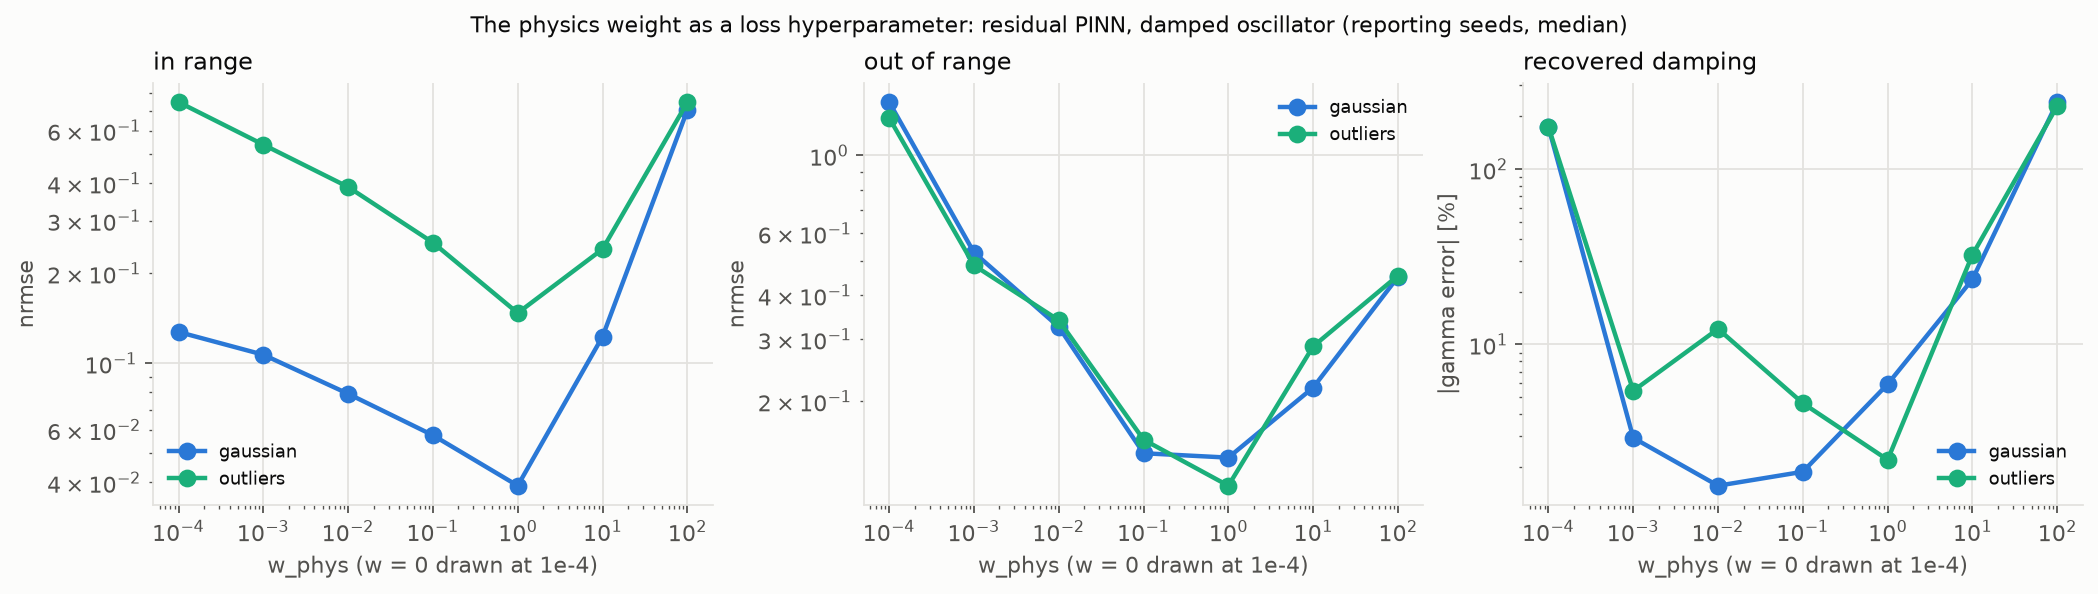

nrmse_in  nrmse_out  err_gamma_pct
noise    w_phys                                     
gaussian 0.000    0.127401   1.417905     173.930943
         0.001    0.106923   0.529670      -2.933791
         0.010    0.079170   0.325466       1.565517
         0.100    0.057525   0.142324       1.879642
         1.000    0.039016   0.138305       5.938217
         10.000   0.122901   0.218777      23.520618
         100.000  0.701992   0.451427     241.213552
outliers 0.000    0.747558   1.277989     173.930943
         0.001    0.538667   0.487096       5.442596
         0.010    0.388957   0.339982     -12.273315
         0.100    0.253468   0.155549      -4.625649
         1.000    0.147401   0.115081      -2.199725
         10.000   0.241039   0.286451      32.473363
         100.000  0.745832   0.455309     228.939007

In [8]:
show("08_w_phys_dial")
load_table("optim", "w_phys_dial").groupby(["noise", "w_phys"])[
    ["nrmse_in", "nrmse_out", "err_gamma_pct"]].median()

## 6. The `balance` option

Until 2026-09-27 the shipped PINN annealed its physics weight from the ratio of gradient norms.
For the shape-B PINN the physics term is `mean(NN^2)`, whose gradient is
proportional to the correction itself, so the weight rises as the correction
shrinks and the correction shrinks as the weight rises. Measured on the real
tracks, tuning seeds only:

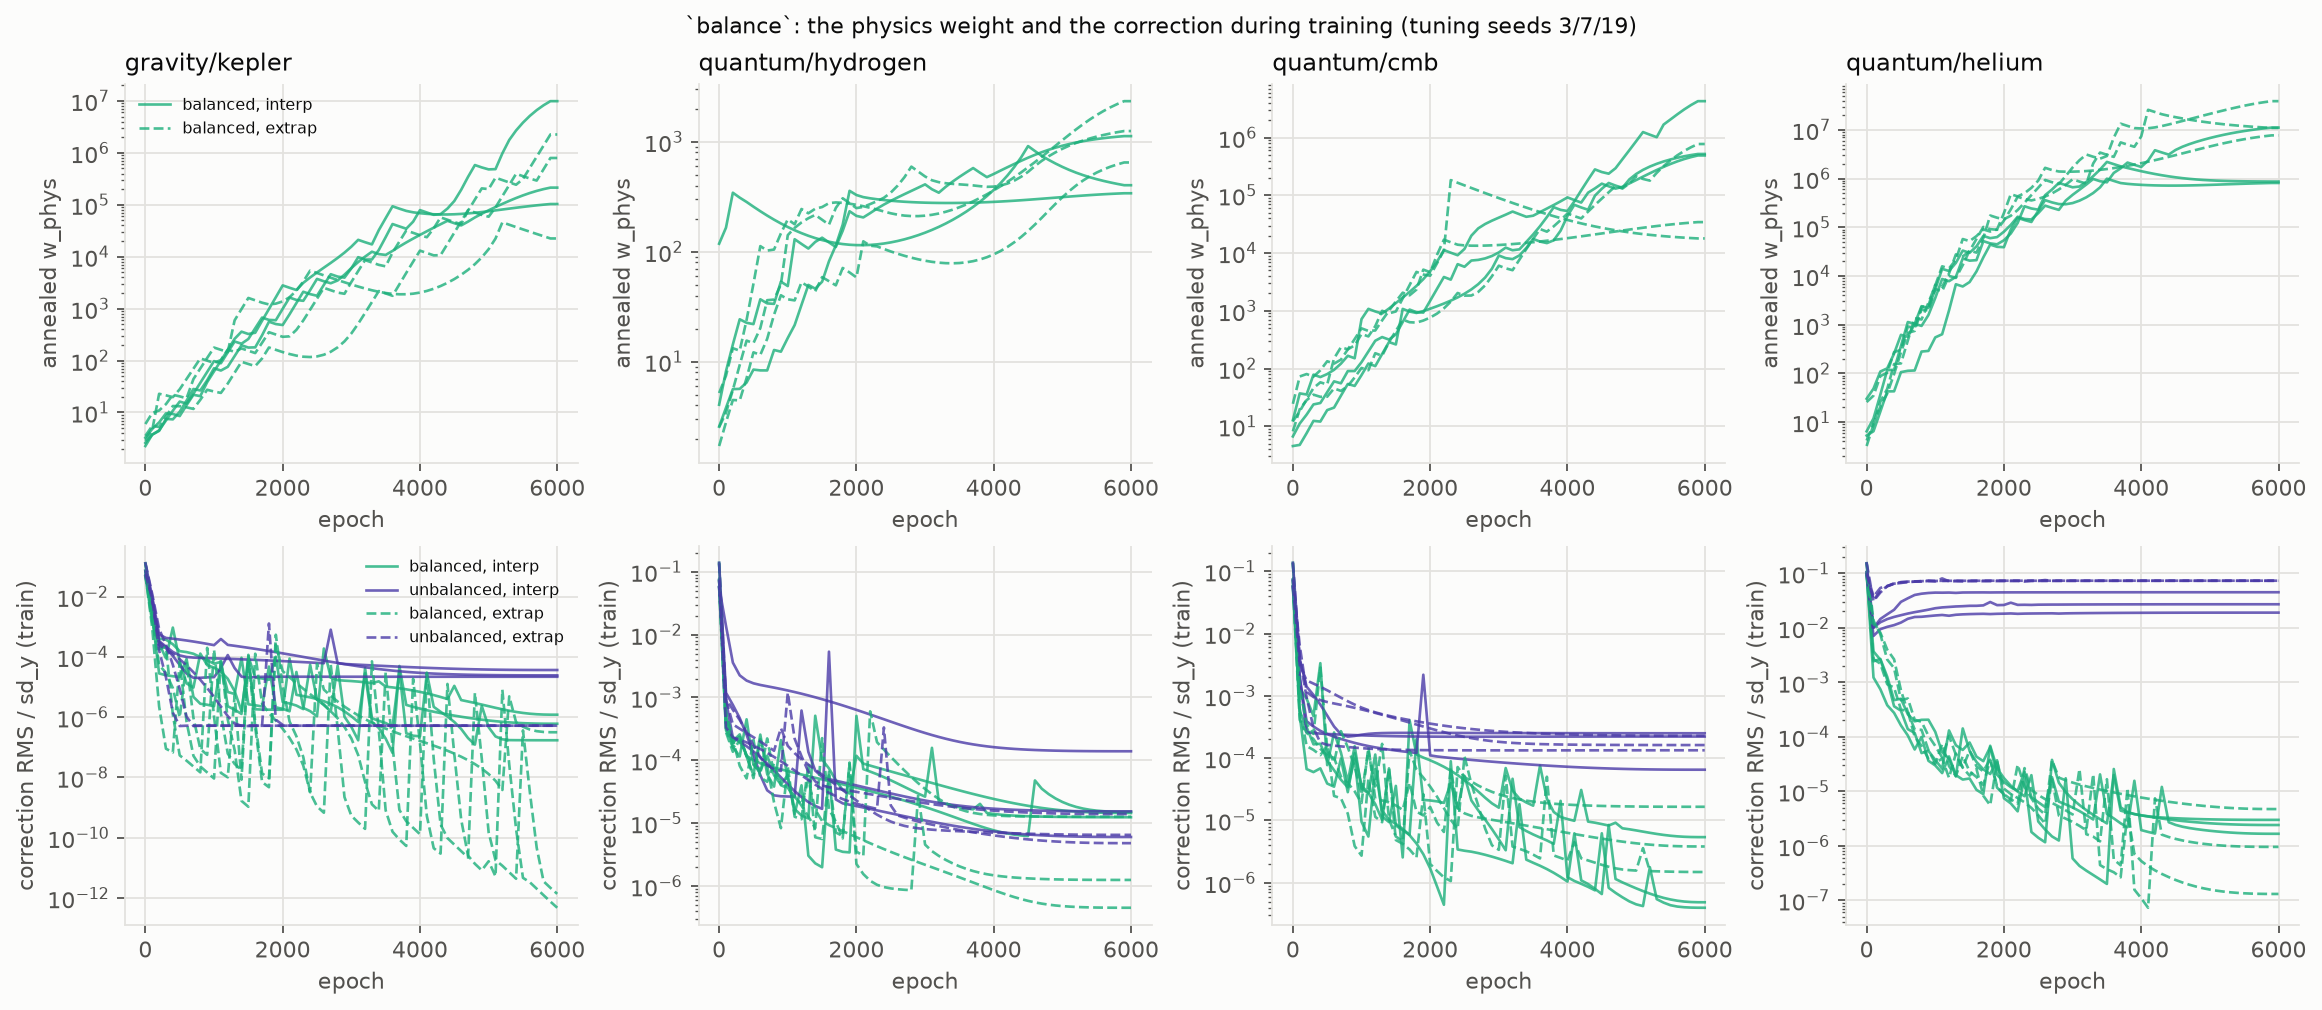

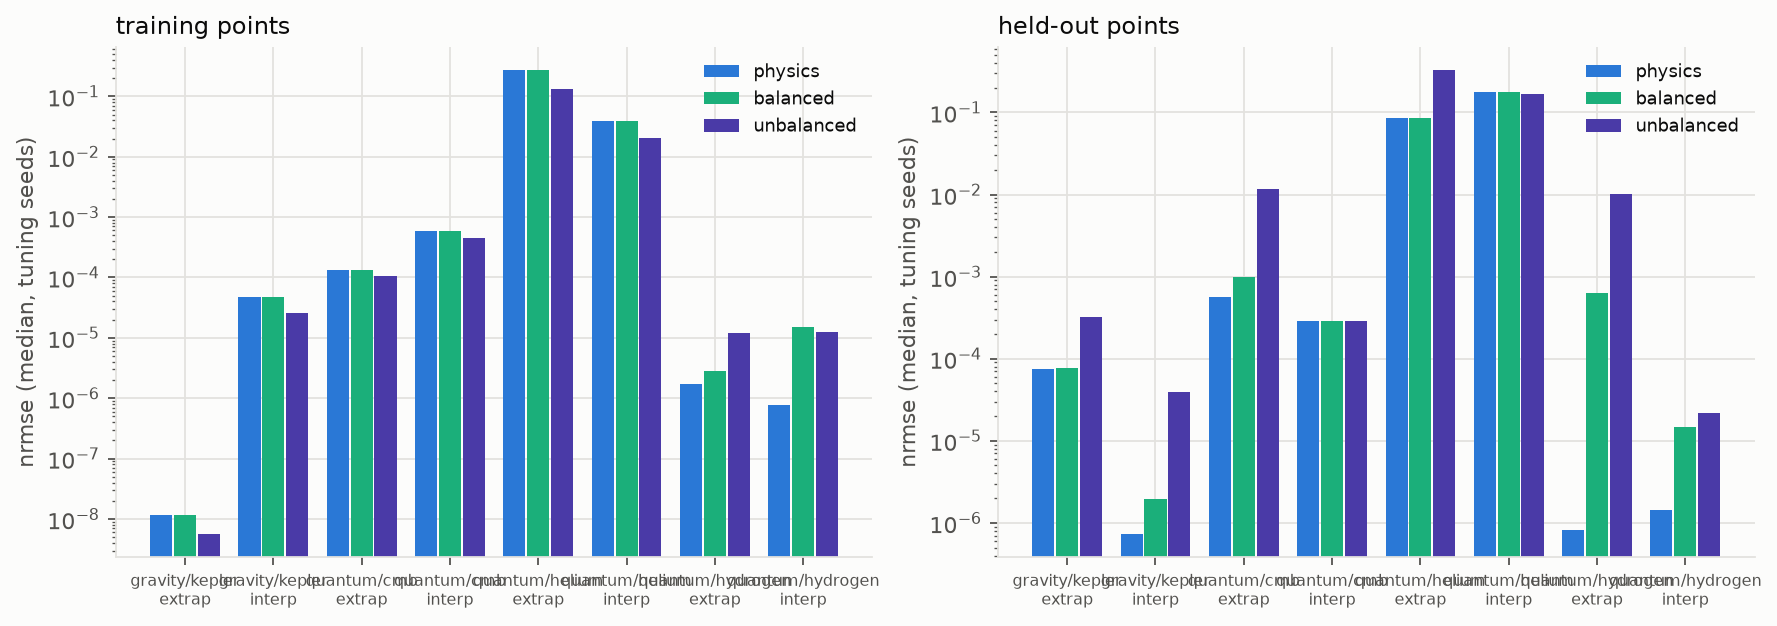

,track,split,variant,w_phys_final,correction_rms_frac,correction_rms_frac_out,nrmse_in,nrmse_out,nrmse_out_vs_physics
0,gravity/kepler,extrap,balanced,7.963470e+05,1.369932e-12,3.542863e-04,1.144903e-08,7.798544e-05,1.031818
1,gravity/kepler,extrap,physics,NaN,NaN,NaN,1.144904e-08,7.558060e-05,1.000000
2,gravity/kepler,extrap,unbalanced,1.000000e+00,5.223073e-07,3.092041e-02,5.724521e-09,3.200940e-04,4.235135
3,gravity/kepler,interp,balanced,2.139413e+05,6.063481e-07,1.146055e-06,4.666813e-05,1.967669e-06,2.657773
4,gravity/kepler,interp,physics,NaN,NaN,NaN,4.665488e-05,7.403450e-07,1.000000
5,gravity/kepler,interp,unbalanced,1.000000e+00,2.441759e-05,3.677462e-05,2.571508e-05,3.982861e-05,53.797372
6,quantum/cmb,extrap,balanced,3.440147e+04,3.826145e-06,1.573719e-03,1.336292e-04,9.913948e-04,1.732114
7,quantum/cmb,extrap,physics,NaN,NaN,NaN,1.344234e-04,5.723611e-04,1.000000
8,quantum/cmb,extrap,unbalanced,1.000000e+00,1.624786e-04,2.575671e-02,1.050290e-04,1.166584e-02,20.381960
9,quantum/cmb,interp,balanced,5.204572e+05,4.865407e-07,7.953656e-07,5.987480e-04,2.884745e-04,1.000583


In [9]:
show("09_balance_history"); show("10_balance_errors")
load_table("optim", "balance_summary")[
    ["track", "split", "variant", "w_phys_final", "correction_rms_frac",
     "correction_rms_frac_out", "nrmse_in", "nrmse_out", "nrmse_out_vs_physics"]]

The written conclusions, with every number read from these tables, are in
`docs/optimization/README.md`.